# 02 - Análisis Exploratorio de Datos (EDA) COVID-19

En este cuaderno se analizan las tendencias globales y por país de los casos confirmados de COVID-19, identificando los picos de contagio en las series temporales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

## 1. Carga de Datos Procesados

In [2]:
data_path = Path("..") / "data" / "covid_confirmed_long.csv"
df = pd.read_csv(data_path, parse_dates=['Date'])

print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (330327, 6)


,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0
1,NaN,Albania,41.15330,20.168300,2020-01-22,0
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0


## 2. Agregación Global

Analizamos la evolución total de los casos confirmados en el mundo.

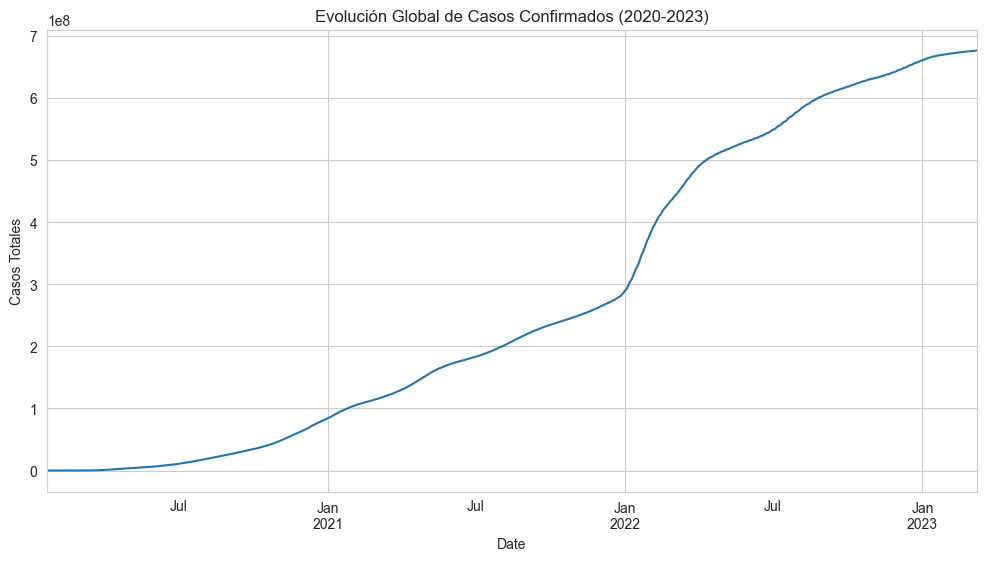

In [3]:
global_cases = df.groupby('Date')['Confirmed'].sum()

plt.figure(figsize=(12, 6))
global_cases.plot()
plt.title("Evolución Global de Casos Confirmados (2020-2023)")
plt.ylabel("Casos Totales")
plt.show()

## 3. Top 5 Países con Mayor Impacto

Filtramos los países con más casos confirmados acumulados.

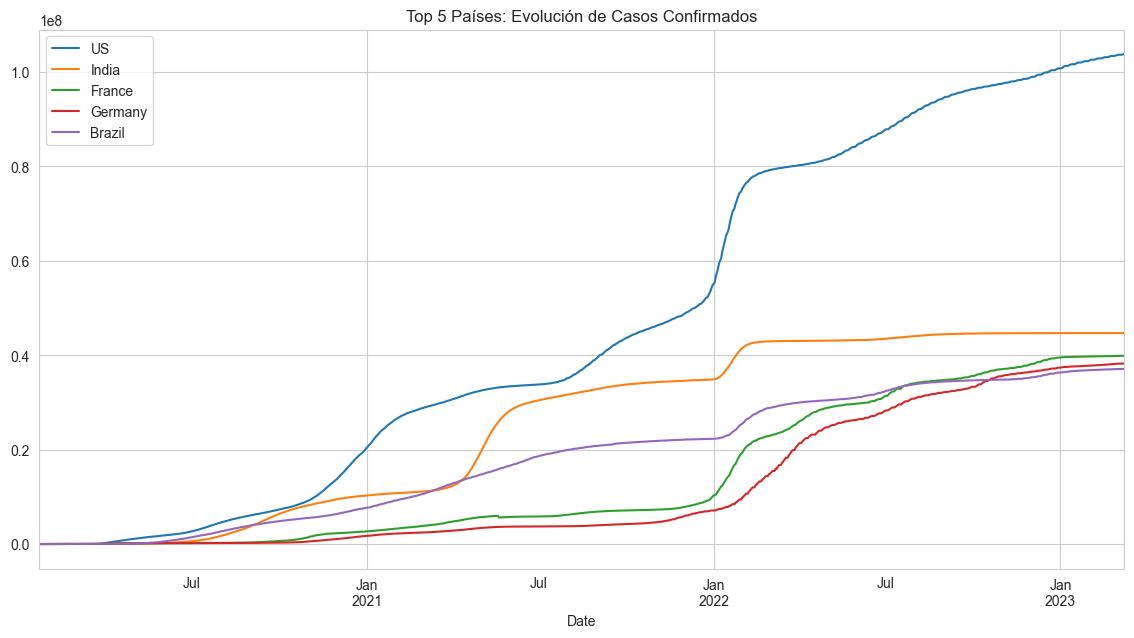

In [4]:
last_date = df['Date'].max()
top_countries = df[df['Date'] == last_date].groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(5).index.tolist()

plt.figure(figsize=(14, 7))
for country in top_countries:
    country_df = df[df['Country/Region'] == country].groupby('Date')['Confirmed'].sum()
    country_df.plot(label=country)

plt.title("Top 5 Países: Evolución de Casos Confirmados")
plt.legend()
plt.show()